# 01 — Análise Exploratória (EDA) — Brasileirão

**Objetivo:** entender a estrutura dos dados antes de qualquer modelagem, seguindo as regras de
regras do projeto.

**Restrições desta notebook (não-negociáveis):**
- Nenhum modelo é treinado aqui — apenas estatística descritiva e visualização.
- `data/train.csv`, `data/test.csv` e `data/sample_submission.csv` são lidos em modo somente-leitura
  e **nunca são alterados/sobrescritos**.
- `train.csv` cobre as temporadas 2013–2021 (contém `Res` e as odds `odd_casa`/`odd_empate`/`odd_visitante`).
  `test.csv` cobre 2022–2026 e **não contém** `Res` nem odds — isso já é uma restrição estrutural do problema,
  não uma escolha nossa.
- O alvo é `Res` ∈ {`H`, `D`, `A`}, avaliado por LogLoss multiclasse com `labels=['A','D','H']`.

**Conteúdo:** (1) esquema e tipos, (2) valores ausentes, (3) distribuição temporal por `Season`,
(4) distribuição do alvo `Res`, (5) riscos de vazamento (leakage) a observar nos próximos notebooks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample_sub = pd.read_csv('../data/sample_submission.csv')

print('train shape:', train.shape)
print('test shape:', test.shape)
print('sample_submission shape:', sample_sub.shape)


train shape: (3419, 26)
test shape: (1725, 22)
sample_submission shape: (1725, 4)


## 1. Esquema e tipos das colunas

In [2]:
schema = pd.DataFrame({
    'dtype_train': train.dtypes.astype(str),
}).join(pd.DataFrame({'dtype_test': test.dtypes.astype(str)}), how='outer')
schema['only_in'] = np.where(schema['dtype_train'].isna(), 'test', np.where(schema['dtype_test'].isna(), 'train', 'both'))
schema


,dtype_train,dtype_test,only_in
Away,str,str,both
Date,str,str,both
Home,str,str,both
Id,int64,int64,both
Res,str,NaN,train
Season,int64,int64,both
away_form_as_visitor,float64,float64,both
elo_away,float64,float64,both
elo_diff,float64,float64,both
elo_home,float64,float64,both


**Observação:** `Res`, `odd_casa`, `odd_empate` e `odd_visitante` existem **apenas em `train.csv`**.
Isso confirma estruturalmente a regra do projeto: essas colunas de odds não podem fazer parte
do pipeline de submissão porque simplesmente não existem em `test.csv` no momento da inferência.


In [3]:
train.head()


,Id,Season,Date,Home,Away,elo_home,elo_away,elo_diff,form_pts_home,form_pts_away,form_gf_home,form_ga_home,form_gf_away,form_ga_away,home_form_as_host,away_form_as_visitor,rest_days_home,rest_days_away,season_ppg_home,season_ppg_away,round_n,h2h_home_pts,Res,odd_casa,odd_empate,odd_visitante
0,0,2013,2013-05-25,Vasco,Portuguesa,1506.636452,1486.580590,20.055862,1.6,1.0,1.2,1.4,0.8,1.2,0.4,1.0,174.0,174.0,NaN,NaN,1,3.0,H,1.86,3.44,4.06
1,1,2013,2013-05-25,Vitoria,Internacional,1500.000000,1490.971962,9.028038,NaN,0.2,NaN,NaN,0.0,1.6,NaN,0.8,NaN,174.0,NaN,NaN,1,NaN,D,2.72,3.17,2.52
2,2,2013,2013-05-26,Corinthians,Botafogo RJ,1527.354763,1506.560479,20.794285,2.0,1.0,2.2,1.0,1.8,1.8,2.2,1.2,175.0,176.0,NaN,NaN,1,0.0,D,1.82,3.43,4.21
3,3,2013,2013-05-26,Criciuma,Bahia,1500.000000,1498.594997,1.405003,NaN,2.0,NaN,NaN,1.0,0.8,NaN,1.4,NaN,175.0,NaN,NaN,1,NaN,H,1.72,3.50,4.70
4,4,2013,2013-05-26,Gremio,Nautico,1561.732962,1489.510755,72.222206,2.2,1.4,1.8,1.0,1.2,0.8,1.8,0.4,175.0,175.0,NaN,NaN,1,3.0,H,1.38,4.36,8.19


In [4]:
test.head()


,Id,Season,Date,Home,Away,elo_home,elo_away,elo_diff,form_pts_home,form_pts_away,form_gf_home,form_ga_home,form_gf_away,form_ga_away,home_form_as_host,away_form_as_visitor,rest_days_home,rest_days_away,season_ppg_home,season_ppg_away,round_n,h2h_home_pts
0,3419,2022,2022-04-09,Fluminense,Santos,1528.746821,1529.010893,-0.264072,1.8,1.6,1.4,0.8,1.0,0.8,3.0,1.6,120.0,120.0,NaN,NaN,1,2.00
1,3420,2022,2022-04-09,Atletico GO,Flamengo RJ,1530.562587,1594.190649,-63.628062,2.6,1.0,1.6,0.6,1.0,1.4,1.8,1.6,120.0,120.0,NaN,NaN,1,1.50
2,3421,2022,2022-04-10,Palmeiras,Ceara,1560.083498,1520.779468,39.304031,1.6,1.0,1.2,0.8,0.8,1.0,2.0,0.8,121.0,121.0,NaN,NaN,1,3.00
3,3422,2022,2022-04-10,Coritiba,Goias,1455.359556,1480.986295,-25.626739,0.6,1.6,0.6,2.0,1.6,1.2,1.2,0.8,408.0,408.0,NaN,NaN,1,1.25
4,3423,2022,2022-04-10,Atletico-MG,Internacional,1621.329870,1510.875054,110.454816,2.0,0.2,2.8,2.4,0.6,1.4,3.0,0.0,121.0,121.0,NaN,NaN,1,1.40


## 2. Valores ausentes

In [5]:
def missing_report(df, name):
    miss = df.isna().sum()
    pct = (miss / len(df) * 100).round(2)
    rep = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
    rep = rep[rep['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    rep.insert(0, 'dataset', name)
    return rep

miss_train = missing_report(train, 'train')
miss_test = missing_report(test, 'test')
miss_all = pd.concat([miss_train, miss_test])
miss_all


,dataset,missing_count,missing_pct
h2h_home_pts,train,656,19.19
season_ppg_home,train,90,2.63
season_ppg_away,train,90,2.63
home_form_as_host,train,16,0.47
away_form_as_visitor,train,16,0.47
form_pts_away,train,9,0.26
form_ga_away,train,9,0.26
rest_days_away,train,9,0.26
form_gf_away,train,9,0.26
form_ga_home,train,7,0.20


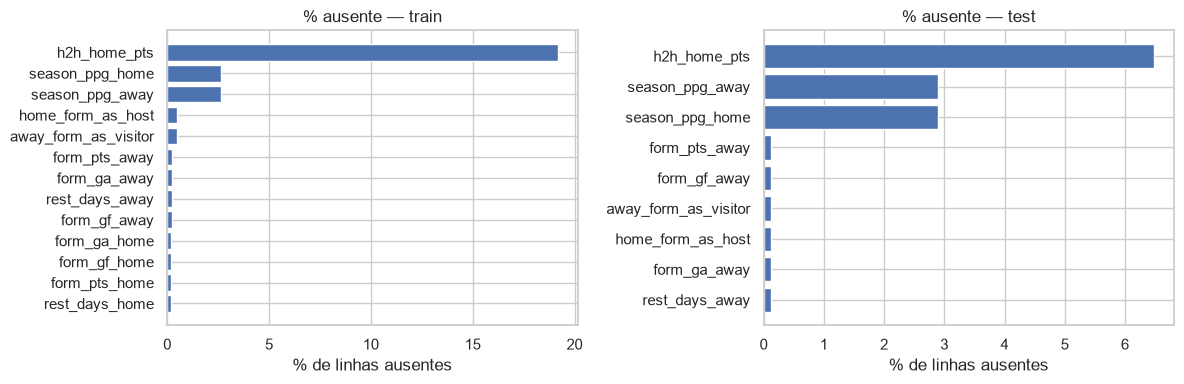

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (name, rep) in zip(axes, [('train', miss_train), ('test', miss_test)]):
    if len(rep) == 0:
        ax.text(0.5, 0.5, 'sem valores ausentes', ha='center', va='center')
        ax.set_title(name)
        continue
    ax.barh(rep.index, rep['missing_pct'], color='#4C72B0')
    ax.set_title(f'% ausente — {name}')
    ax.set_xlabel('% de linhas ausentes')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Por que existem NaNs?** As colunas de forma recente (`form_pts_*`, `form_gf_*`, `form_ga_*`,
`home_form_as_host`, `away_form_as_visitor`), de desempenho na temporada (`season_ppg_*`) e de confronto
direto (`h2h_home_pts`) são calculadas a partir do **histórico de partidas anteriores**. No início de cada
temporada (rodadas iniciais) ainda não há partidas suficientes para calcular essas métricas, gerando `NaN`.
Isso é esperado e **não é vazamento** — é só ausência de histórico suficiente. Precisará ser tratado com
imputação (ajustada apenas nos dados de treino de cada fold) nos notebooks seguintes.


In [7]:
# Confirma a hipótese: NaN concentrado nas primeiras rodadas de cada temporada
cols_forma = ['form_pts_home', 'season_ppg_home', 'h2h_home_pts']
train.assign(is_na=train[cols_forma].isna().any(axis=1)).groupby(['Season', 'is_na']).size().unstack(fill_value=0).head(10)


is_na,False,True
Season,,
2013,234,146
2014,310,70
2015,294,86
2016,297,82
2017,357,23
2018,294,86
2019,294,86
2020,321,59
2021,290,90


## 3. Distribuição temporal por `Season`

In [8]:
season_counts = pd.concat([
    train['Season'].value_counts().sort_index().rename('train'),
    test['Season'].value_counts().sort_index().rename('test'),
], axis=1)
season_counts


,train,test
Season,,
2013,380.0,NaN
2014,380.0,NaN
2015,380.0,NaN
2016,379.0,NaN
2017,380.0,NaN
2018,380.0,NaN
2019,380.0,NaN
2020,380.0,NaN
2021,380.0,NaN


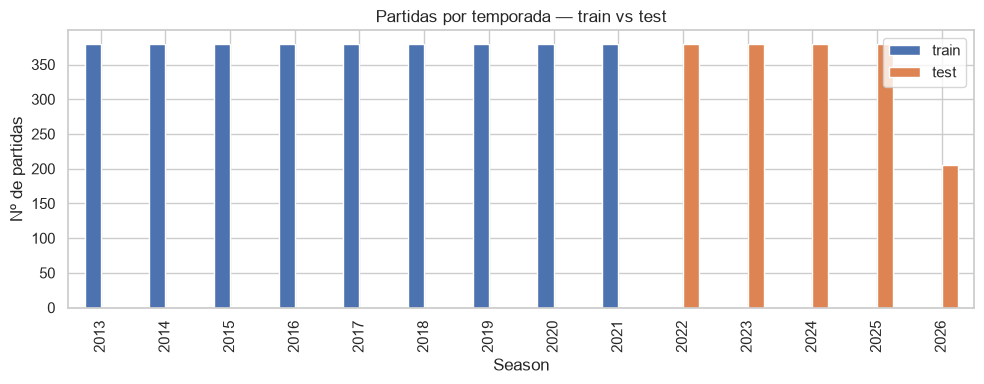

Temporadas em train: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Temporadas em test : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Há sobreposição de temporadas entre train e test? False


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
season_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Nº de partidas')
ax.set_title('Partidas por temporada — train vs test')
plt.tight_layout()
plt.show()

print('Temporadas em train:', sorted(train['Season'].unique()))
print('Temporadas em test :', sorted(test['Season'].unique()))
print('Há sobreposição de temporadas entre train e test?',
      bool(set(train['Season'].unique()) & set(test['Season'].unique())))


`train.csv` cobre as temporadas **2013–2021** (9 temporadas) e `test.csv` cobre **2022–2026**
(5 temporadas), sem nenhuma sobreposição. Isso confirma que o split é temporal por natureza: qualquer
validação precisa respeitar essa ordem cronológica (treinar no passado, validar no futuro), nunca embaralhar
partidas de temporadas diferentes.


## 4. Distribuição do alvo `Res`

In [10]:
res_counts = train['Res'].value_counts().reindex(['A', 'D', 'H'])
res_pct = (res_counts / res_counts.sum() * 100).round(2)
pd.DataFrame({'count': res_counts, 'pct': res_pct})


,count,pct
Res,,
A,821,24.01
D,917,26.82
H,1681,49.17


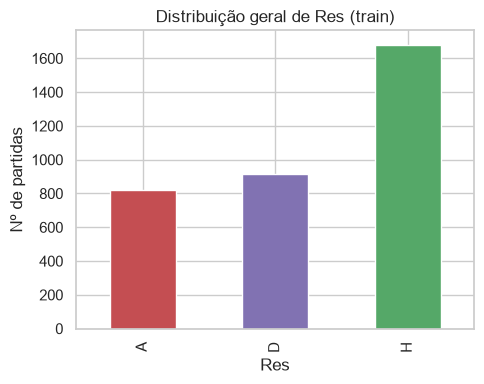

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
res_counts.plot(kind='bar', ax=ax, color=['#C44E52', '#8172B2', '#55A868'])
ax.set_title('Distribuição geral de Res (train)')
ax.set_ylabel('Nº de partidas')
plt.tight_layout()
plt.show()


In [12]:
res_by_season = train.groupby('Season')['Res'].value_counts(normalize=True).unstack().reindex(columns=['A', 'D', 'H'])
res_by_season


Res,A,D,H
Season,,,
2013,0.231579,0.284211,0.484211
2014,0.239474,0.242105,0.518421
2015,0.234211,0.239474,0.526316
2016,0.218997,0.248021,0.532982
2017,0.289474,0.271053,0.439474
2018,0.178947,0.289474,0.531579
2019,0.257895,0.257895,0.484211
2020,0.265789,0.284211,0.450000
2021,0.244737,0.297368,0.457895


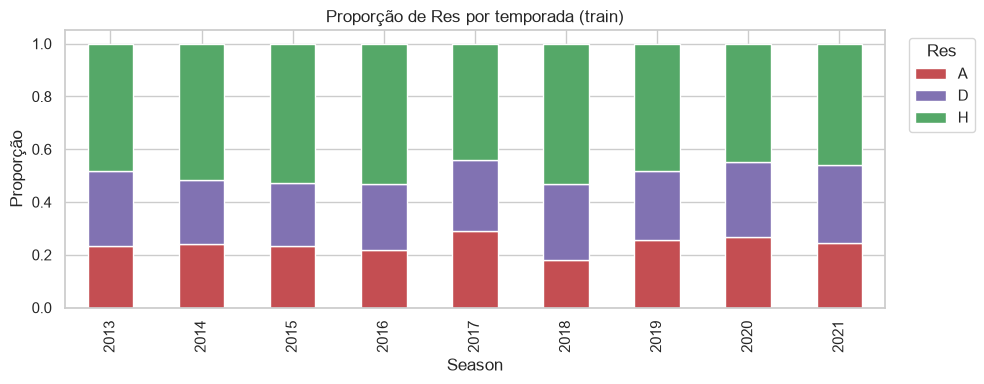

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
res_by_season.plot(kind='bar', stacked=True, ax=ax, color=['#C44E52', '#8172B2', '#55A868'])
ax.set_ylabel('Proporção')
ax.set_title('Proporção de Res por temporada (train)')
ax.legend(title='Res', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


O resultado `H` (vitória do mandante) é a classe majoritária em todas as temporadas (~44–49%),
seguido por `D` e `A`, mas a proporção exata **varia de temporada para temporada** — não é uma distribuição
fixa. Isso reforça a necessidade de uma validação **walk-forward por temporada** (em vez de um único split
aleatório): um baseline de frequência histórica recalculado por fold pode capturar melhor esse
comportamento do que uma frequência global fixa, e o desempenho de qualquer modelo deve ser medido
temporada a temporada, não só em média.


## 5. Riscos de vazamento (leakage) a observar

In [14]:
print('odd_* presentes em test.csv?', any(c in test.columns for c in ['odd_casa', 'odd_empate', 'odd_visitante']))
print('Res presente em test.csv?', 'Res' in test.columns)
print('Ids de train e test se sobrepõem?', bool(set(train['Id']) & set(test['Id'])))
print('Id é estritamente crescente com o tempo em train?', train['Id'].is_monotonic_increasing)


odd_* presentes em test.csv? False
Res presente em test.csv? False
Ids de train e test se sobrepõem? False
Id é estritamente crescente com o tempo em train? True


Principais riscos identificados para os próximos notebooks:

1. **Odds como feature de teste (proibido).** `odd_casa`/`odd_empate`/`odd_visitante` só existem em
   `train.csv` e não podem entrar no pipeline de submissão (regra do projeto). Podem ser usadas
   apenas para análise diagnóstica isolada em treino, nunca dentro do pipeline de inferência.
2. **Recalcular features usando `test.csv`.** Colunas como `elo_*`, `form_*`, `season_ppg_*` e
   `h2h_home_pts` já vêm pré-calculadas a partir do histórico. É proibido recalculá-las (ou qualquer nova
   feature) usando outras linhas de `test.csv` — cada predição só pode depender da própria linha de teste e
   de `train.csv`.
3. **Vazamento entre linhas de `test.csv`.** Ordenar, agrupar, ou usar estatísticas (média, contagem,
   shift) calculadas sobre múltiplas linhas de `test.csv` para gerar uma feature vazaria informação sobre
   partidas "futuras" em relação à predição de uma linha específica.
4. **Shuffle na validação.** Como o problema é sequencial por temporada, qualquer
   `train_test_split(..., shuffle=True)` ou k-fold aleatório misturaria passado e futuro — a validação deve
   ser sempre walk-forward por `Season`.
5. **Ajuste de transformadores fora do fold de treino.** Imputação, encoding, escala, seleção de
   features e calibração devem ser ajustados **somente** na porção de treino de cada fold, nunca no fold de
   validação nem no leaderboard público.
6. **Mudança de composição de times entre temporadas.** Promoção/rebaixamento faz com que times apareçam
   ou desapareçam de uma temporada para outra — um encoding de time (ex.: one-hot de `Home`/`Away`) treinado
   em temporadas antigas pode não cobrir times novos em temporadas futuras; isso deve ser tratado com
   `handle_unknown='ignore'` quando esse tipo de feature for introduzido.
7. **LogLoss "bom demais para ser verdade".** Segundo o enunciado, o benchmark sem modelo é ≈1.0594 e
   o baseline inicial é ≈1.047. Um LogLoss abaixo de ~1.000 na validação temporal é considerado suspeito e
   deve disparar uma auditoria de vazamento antes de ser aceito como resultado válido.


## Conclusão

- Dados limpos estruturalmente: `test.csv` já não contém `Res` nem odds, então essas restrições são
  garantidas pelo próprio dataset — o cuidado deve estar no *pipeline* (não reintroduzir essas colunas via
  merge/lookup indevido).
- NaNs em colunas de forma/ppg/h2h são esperados no início de cada temporada e serão tratados com
  imputação ajustada por fold.
- `train.csv` (2013–2021) e `test.csv` (2022–2026) não se sobrepõem — a validação deve ser
  **walk-forward por `Season`**, sem shuffle.
- A distribuição de `Res` varia por temporada, o que motiva recalcular o baseline de frequência histórica
  em cada fold em vez de usar uma frequência global fixa.
- Próximo passo (`02_baseline_temporal.ipynb`): implementar a validação walk-forward por temporada e
  comparar o baseline de frequência histórica com uma regressão logística multinomial usando apenas
  features permitidas.
